# 4.4.1 离散映射的不动点与周期

## 学习目标与先修知识

能区分代次映射和微分方程，证明 logistic 映射（logistic map）的区间保持性，用扰动倍率判断不动点（fixed point）稳定，并识别周期二（period-two cycle）行为。

先修：第 2 篇的递推；前面章节的局部线性化（linearization）、周期与分岔（bifurcation）。 [复习上一节](../03-分岔与参数变化/02-从平衡到周期的Hopf转变.ipynb)。

## 具体问题

若按不重叠世代记录种群，每一代出生和存活过程压缩成一次更新，规则可以完全确定，但后段却未必趋于一个常数。为什么不能直接套用一维连续流的结论？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
x=.25;values=[x]
for _ in range(4):x=2*x*(1-x);values.append(x)
display(Markdown(show_table(['代次 n','x[n]'],enumerate(values))))

| 代次 n | x[n] |
| --- | --- |
| 0 | 0.25 |
| 1 | 0.375 |
| 2 | 0.46875 |
| 3 | 0.498047 |
| 4 | 0.499992 |

## 模型假设

模型（model）为 x[n+1]=r*x[n]*(1−x[n])，n 是离散代次；x 为经尺度归一的非负比例，r 为每代无量纲（dimensionless）参数（parameter）。只在 0≤r≤4、0≤x0≤1 下讨论，避免未经说明地把越界值当作生物量。

这是忽略年龄结构、迁移、环境变化和随机性的理想代次模型，不是连续 logistic 微分方程的任意步长近似。实验固定 x0=0.2，分别用 r=2.8、3.2、3.9；另画 r=3.2 的两步几何关系。

## 数学解释与推导

映射 F(x)=rx(1−x) 把当前代直接变成下一代，不是 x+hF(x)。因为 0≤x(1−x)≤1/4，所以在约定参数范围内 0≤F(x)≤1；这是有界性的解析依据。

不动点满足 x*=F(x*)：得到 0，以及 r≠0 时的 1−1/r。对 r>1，后一项位于区间内部。令小扰动 δ_n=x_n−x*，则
$$\delta_{n+1}\approx F'(x_*)\delta_n,\qquad F'(x)=r(1-2x).$$
连续流比较的是指数中的实部，离散映射则需 |F′|<1，才能每步缩小。负倍率会交替两侧，但只要绝对值小于 1 仍可收敛；绝对值大于 1 则放大。

零点在 0≤r<1 时吸引；非零点的倍率为 2−r，因此在 1<r<3 时局部吸引。r=1 或 3 是严格线性判据的边界，不能从等号直接判断全部非线性行为。

周期二是 p≠q、F(p)=q、F(q)=p。两步扰动倍率为 F′(p)F′(q)，仍需绝对值小于 1。对 r>3，非平凡二周期的两值为
$$p,q=\frac{r+1\mp\sqrt{(r-3)(r+1)}}{2r}.$$
这可由 F(F(x))−x=0 去掉不动点因子后求二次方程得到。取 r=3.2，可以将计算出的两值代回两步映射核对。

蛛网图（cobweb diagram）把点从 y=x 垂直移到 y=F(x)，再水平回到 y=x，重复构成一代一代的更新。它表达迭代几何，不是连续时间相轨迹（phase trajectory）。

## 核心实现

将推导中的每一步明确写成计算。

In [3]:
def logistic_path(r,initial,steps):
    values=[initial]
    for _ in range(steps):values.append(r*values[-1]*(1-values[-1]))
    return values

## 对照实验

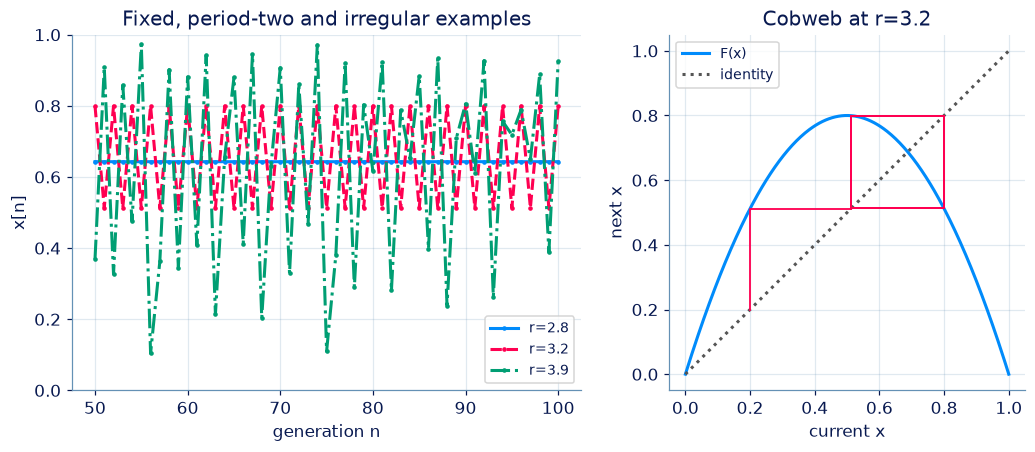

In [4]:
fig,axes=plt.subplots(1,2,figsize=(10,4))
for r,color,style in [(2.8,BLUE,'-'),(3.2,PINK,'--'),(3.9,GREEN,'-.')]:
    states=logistic_path(r,.2,100)
    axes[0].plot(range(50,101),states[50:],color=color,ls=style,marker='o',ms=2,label=f'r={r}')
grid=np.linspace(0,1,301);r=3.2
axes[1].plot(grid,r*grid*(1-grid),color=BLUE,label='F(x)')
axes[1].plot(grid,grid,color=GRAY,ls=':',label='identity')
x=.2
for _ in range(14):
    nxt=r*x*(1-x)
    axes[1].plot([x,x,nxt],[x,nxt,nxt],color=PINK,lw=1.2)
    x=nxt
axes[0].set(xlabel='generation n',ylabel='x[n]',ylim=(0,1),title='Fixed, period-two and irregular examples')
axes[1].set(xlabel='current x',ylabel='next x',aspect='equal',title='Cobweb at r=3.2')
for ax in axes:ax.legend(fontsize=9)
plt.show()

## 结果解释

后段分别呈现一个常值、两点交替与不规则序列。为理解 r=3.9 的不规则变化，接下来比较邻近轨迹（trajectory）的分离，并改变观察窗口与计算精度。

每一代有明确含义，不能用“把 h 减半”保持同一个原映射。若确有生物机制允许缩短时间单位，需重新建立对应模型。

### 独立核对

用代数二周期和两步倍率核对长期迭代，而不是仅按图上的两团点分类。

In [5]:
r=3.2
p=(r+1-np.sqrt((r-3)*(r+1)))/(2*r)
q=(r+1+np.sqrt((r-3)*(r+1)))/(2*r)
assert abs(r*p*(1-p)-q)<1e-14 and abs(r*q*(1-q)-p)<1e-14
multiplier=r*(1-2*p)*r*(1-2*q)
assert abs(multiplier)<1
tail=np.array(logistic_path(r,.2,300)[-20:])
assert np.max(np.minimum(abs(tail-p),abs(tail-q)))<1e-10
assert logistic_path(4,1,3)==[1,0,0,0]
print('解析二周期',p,q,'两步倍率',multiplier)

解析二周期 0.5130445095326299 0.7994554904673701 两步倍率 0.15999999999999912


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/04-04-混沌与可预测范围/explore/)：先预测条件变化的后果，再用交互对照本节推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：按代次更新一个比例

离散种群比例满足 x[n+1]=r*x[n]*(1−x[n])。返回从初值（initial condition）开始的全部 steps+1 项，不能把它当作微分方程欧拉更新。

**函数与代码模板**

```python
def solve(
    r: float,
    initial: float,
    steps: int,
) -> list[float]:
    # 根据已知条件计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `r` | `float` | 每代无量纲（dimensionless）参数（parameter）。 | 1 |
| `initial` | `float` | 第 0 代比例。 | 1 |
| `steps` | `int` | 更新代数。 | 1 |

**返回值**

直接返回 states（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 包含初值的序列。 | 1 |

**计算规则**

每代直接令 next=r*x*(1−x)，不加回 x，不引入 h。 为固定浮点实验，使用 Python float；每次更新按 (r*x)*(1-x) 的括号次序，不改写成 r*(x-x*x)。长轨迹（trajectory）的舍入差异会被放大。

**约束与边界**

- 所有输入（input）数值有限；不修改输入列表。
- 0≤r≤4；0≤initial≤1；0≤steps≤200。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| r | 每代无量纲（dimensionless）参数（parameter）。 | 2 | 1 |
| initial | 第 0 代比例。 | 0.25 | 1 |
| steps | 更新代数。 | 3 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
r = 2
initial = 0.25
steps = 3

result = solve(r, initial, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 包含初值的序列。 | [0.25, 0.375, 0.46875, 0.498046875] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.25, 0.375, 0.46875, 0.498046875]
```

**样例解释**

序列为 [0.25,0.375,0.46875,0.498046875]；每步直接使用映射右端。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：按代次更新一个比例](http://127.0.0.1:8000/chapters/04-04-%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%8F%AF%E9%A2%84%E6%B5%8B%E8%8C%83%E5%9B%B4/practice/?question=p04-logistic-iterate)

### 第 2 题 · 多项选择题：为什么选择 0≤r≤4

logistic 映射（logistic map）中 x∈[0,1]。哪些成立？

- **A.** 0≤r≤4 时下一代仍在 [0,1]。
- **B.** 只要初值（initial condition）在 [0,1]，任意 r 都保持区间。
- **C.** 这个区间结论不等于任意 r 都有相同长期行为。
- **D.** x(1−x) 在区间内非负且不超过 1/4。

[作答：为什么选择 0≤r≤4](http://127.0.0.1:8000/chapters/04-04-%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%8F%AF%E9%A2%84%E6%B5%8B%E8%8C%83%E5%9B%B4/practice/?question=p04-interval-invariance)

### 第 3 题 · 单项选择题：映射的不动点如何判断稳定

非零不动点（fixed point） x*=1−1/r（r>1），映射导数（derivative）在该点为 2−r。哪个是局部吸引的严格条件？

- **A.** 2−r>0 即可。
- **B.** 任何 r>1 都局部吸引。
- **C.** 2−r<0 即可。
- **D.** |2−r|<1，即 1<r<3。

[作答：映射的不动点如何判断稳定](http://127.0.0.1:8000/chapters/04-04-%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%8F%AF%E9%A2%84%E6%B5%8B%E8%8C%83%E5%9B%B4/practice/?question=p04-map-stability)

### 第 4 题 · 单项选择题：两点交替属于混沌吗

参数（parameter） r=3.2 的后段序列在两个值附近交替，步进规则确定。哪项正确？

- **A.** 两点周期违反一维 ODE 无周期结论，因此程序错了。
- **B.** 只要一直变化就是混沌（chaos）。
- **C.** 周期二（period-two cycle）行为与混沌不同；需继续检查长期重复和初值敏感性（sensitivity to initial conditions）。
- **D.** 只有随机数能产生交替。

[作答：两点交替属于混沌吗](http://127.0.0.1:8000/chapters/04-04-%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%8F%AF%E9%A2%84%E6%B5%8B%E8%8C%83%E5%9B%B4/practice/?question=p04-periodic-not-chaotic)